# Análise Exploratória dos Dados de Segurança do ISP

## Configurações iniciais do projeto

Importando as bibliotecas e dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../datasets/BaseDPEvolucaoMensalCisp.csv", sep=";", decimal=",", encoding="latin1")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 37588 entries, 0 to 37587
Data columns (total 65 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cisp                        37588 non-null  int64  
 1   mes                         37588 non-null  int64  
 2   ano                         37588 non-null  int64  
 3   mes_ano                     37588 non-null  str    
 4   aisp                        37588 non-null  int64  
 5   risp                        37588 non-null  int64  
 6   munic                       37588 non-null  str    
 7   mcirc                       37588 non-null  int64  
 8   regiao                      37588 non-null  str    
 9   hom_doloso                  37588 non-null  int64  
 10  lesao_corp_morte            37588 non-null  int64  
 11  latrocinio                  37588 non-null  int64  
 12  cvli                        37588 non-null  int64  
 13  hom_por_interv_policial     37588 non-null

Configurando visual dos gráficos

In [3]:
sequentialpalette = sns.color_palette('inferno')
qualitativepalette = sns.color_palette('colorblind')

sns.set_palette(palette=sequentialpalette)

sns.set_style("whitegrid")

In [4]:
# pegar apenas os dados da Capital e da Baixada
df = df[df["regiao"].isin(["Capital", "Baixada Fluminense"])]
df.info()

<class 'pandas.DataFrame'>
Index: 16472 entries, 0 to 37510
Data columns (total 65 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cisp                        16472 non-null  int64  
 1   mes                         16472 non-null  int64  
 2   ano                         16472 non-null  int64  
 3   mes_ano                     16472 non-null  str    
 4   aisp                        16472 non-null  int64  
 5   risp                        16472 non-null  int64  
 6   munic                       16472 non-null  str    
 7   mcirc                       16472 non-null  int64  
 8   regiao                      16472 non-null  str    
 9   hom_doloso                  16472 non-null  int64  
 10  lesao_corp_morte            16472 non-null  int64  
 11  latrocinio                  16472 non-null  int64  
 12  cvli                        16472 non-null  int64  
 13  hom_por_interv_policial     16472 non-null  int

Percebemos que as regiões com mais incidência são bairros nobres, como Barra da Tijuca e Botafogo. Pensamos em duas interpretações disso:
1. Existe um viés no dado, pois esses contam apenas os furtos reportados e registrados.
2. Os dados ainda não estão normalizados pela quantidade de pessoas.
Podemos evitar o 2 ao relacionar com a população de cada bairro, porém precisamos de dados os quais ainda não temos para isso.

Verificamos que não temos nulos.

In [5]:
df.isna().sum()

cisp                         0
mes                          0
ano                          0
mes_ano                      0
aisp                         0
                            ..
encontro_ossada              0
pol_militares_mortos_serv    0
pol_civis_mortos_serv        0
registro_ocorrencias         0
fase                         0
Length: 65, dtype: int64

Verificando que os dados pegam o histórico de 2003 até 2026.

In [6]:
print(f"Min: {df["ano"].min()}, Max: {df["ano"].max()}")

Min: 2003, Max: 2026


## Exploração de furtos e roubos em coletivos

Explorando a base de dados, achamos a coluna "roubo_em_coletivo" e "furto_coletivo", ambas que dizem respeito a segurança no transporte público.
Além disso, temos os campos "cisp", "aisp" e "risp", que servem de proxy com diferentes níveis de granularidade para as regiões para nas quais os incidentes foram reportados. Podemos ver mais a respeito sobre essas regiões [nesse documento](https://www.ispdados.rj.gov.br/Arquivos/Relacaodas%20RISP_AISP.pdf).

In [7]:
df_coletivo = df[["roubo_em_coletivo", "furto_coletivo", "risp", "aisp", "cisp"]]
df_coletivo.groupby("cisp").sum().sort_values("furto_coletivo")

,roubo_em_coletivo,furto_coletivo,risp,aisp
cisp,,,,
45,18,20,61,976
67,66,50,549,6222
51,53,60,837,6696
61,276,148,837,4185
63,317,207,801,6408
...,...,...,...,...
35,4602,5857,558,11034
4,4175,6744,279,1395
32,4992,6832,558,5022


In [8]:
# sns.heatmap(df[["furto_coletivo", "cisp"]].corr())

df[["furto_coletivo", "roubo_em_coletivo", "hom_culposo", "hom_doloso"]].corr()

,furto_coletivo,roubo_em_coletivo,hom_culposo,hom_doloso
furto_coletivo,1.000000,0.224722,0.061425,-0.099689
roubo_em_coletivo,0.224722,1.000000,0.227111,0.281328
hom_culposo,0.061425,0.227111,1.000000,0.368561
hom_doloso,-0.099689,0.281328,0.368561,1.000000


### Roubos e furtos em coletivos através do tempo
Observando os dados através do tempo categorizados por risp, vemos que os roubos em coletivo tiveram um aumento de reportagem em 2016, mas uma queda durante a pandemia, de forma a se estabilizar em valore semelhantes aos anteriores a 2013.
Os furtos rapidamente se recuperaram no pós pandemia.

/tmp/ipykernel_5305/3330847888.py:2: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  sns.barplot(data=df, x="ano", y="roubo_em_coletivo", hue="risp", estimator="sum", palette=qualitativepalette)
/tmp/ipykernel_5305/3330847888.py:4: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  sns.barplot(data=df, x="ano", y="furto_coletivo", hue="risp", estimator="sum", palette=qualitativepalette)


<Axes: xlabel='ano', ylabel='furto_coletivo'>

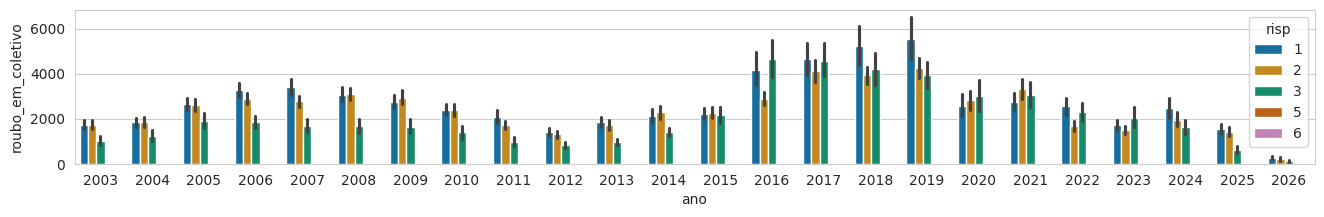

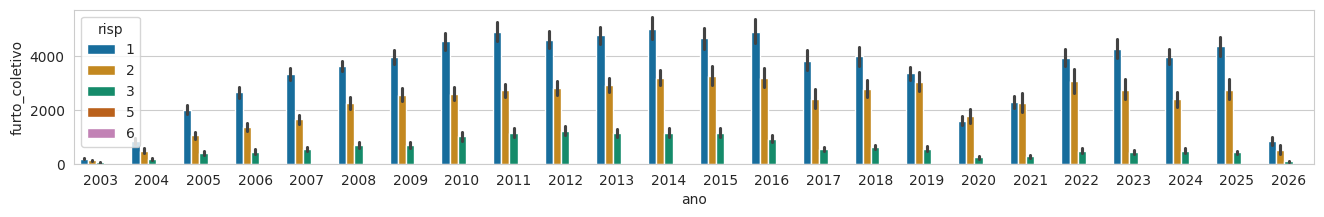

In [9]:

plt.figure(figsize=(16,2))
sns.barplot(data=df, x="ano", y="roubo_em_coletivo", hue="risp", estimator="sum", palette=qualitativepalette)
plt.figure(figsize=(16,2))
sns.barplot(data=df, x="ano", y="furto_coletivo", hue="risp", estimator="sum", palette=qualitativepalette)


Vemos que os furtos e roubos em coletivo são uma parte bem pequena dos furtos e roubos totais.

<Axes: xlabel='ano', ylabel='total_furtos'>

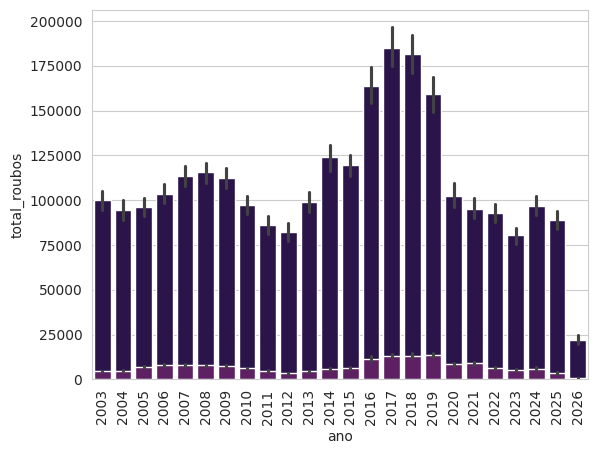

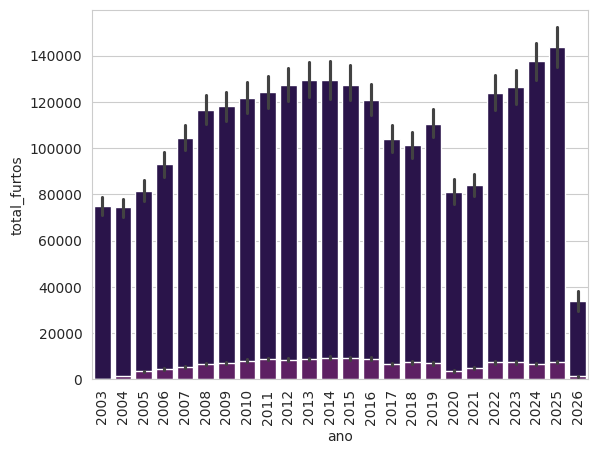

In [10]:
plt.figure()
plt.xticks(rotation=90)
sns.barplot(data=df, x="ano", y="total_roubos", estimator="sum")
sns.barplot(data=df, x="ano", y="roubo_em_coletivo", estimator="sum")
plt.figure()
plt.xticks(rotation=90)
sns.barplot(data=df, x="ano", y="total_furtos", estimator="sum")
sns.barplot(data=df, x="ano", y="furto_coletivo", estimator="sum")

### Buscando correlações entre as colunas
Primeiramente, uma visão geral da correlação

<Axes: >

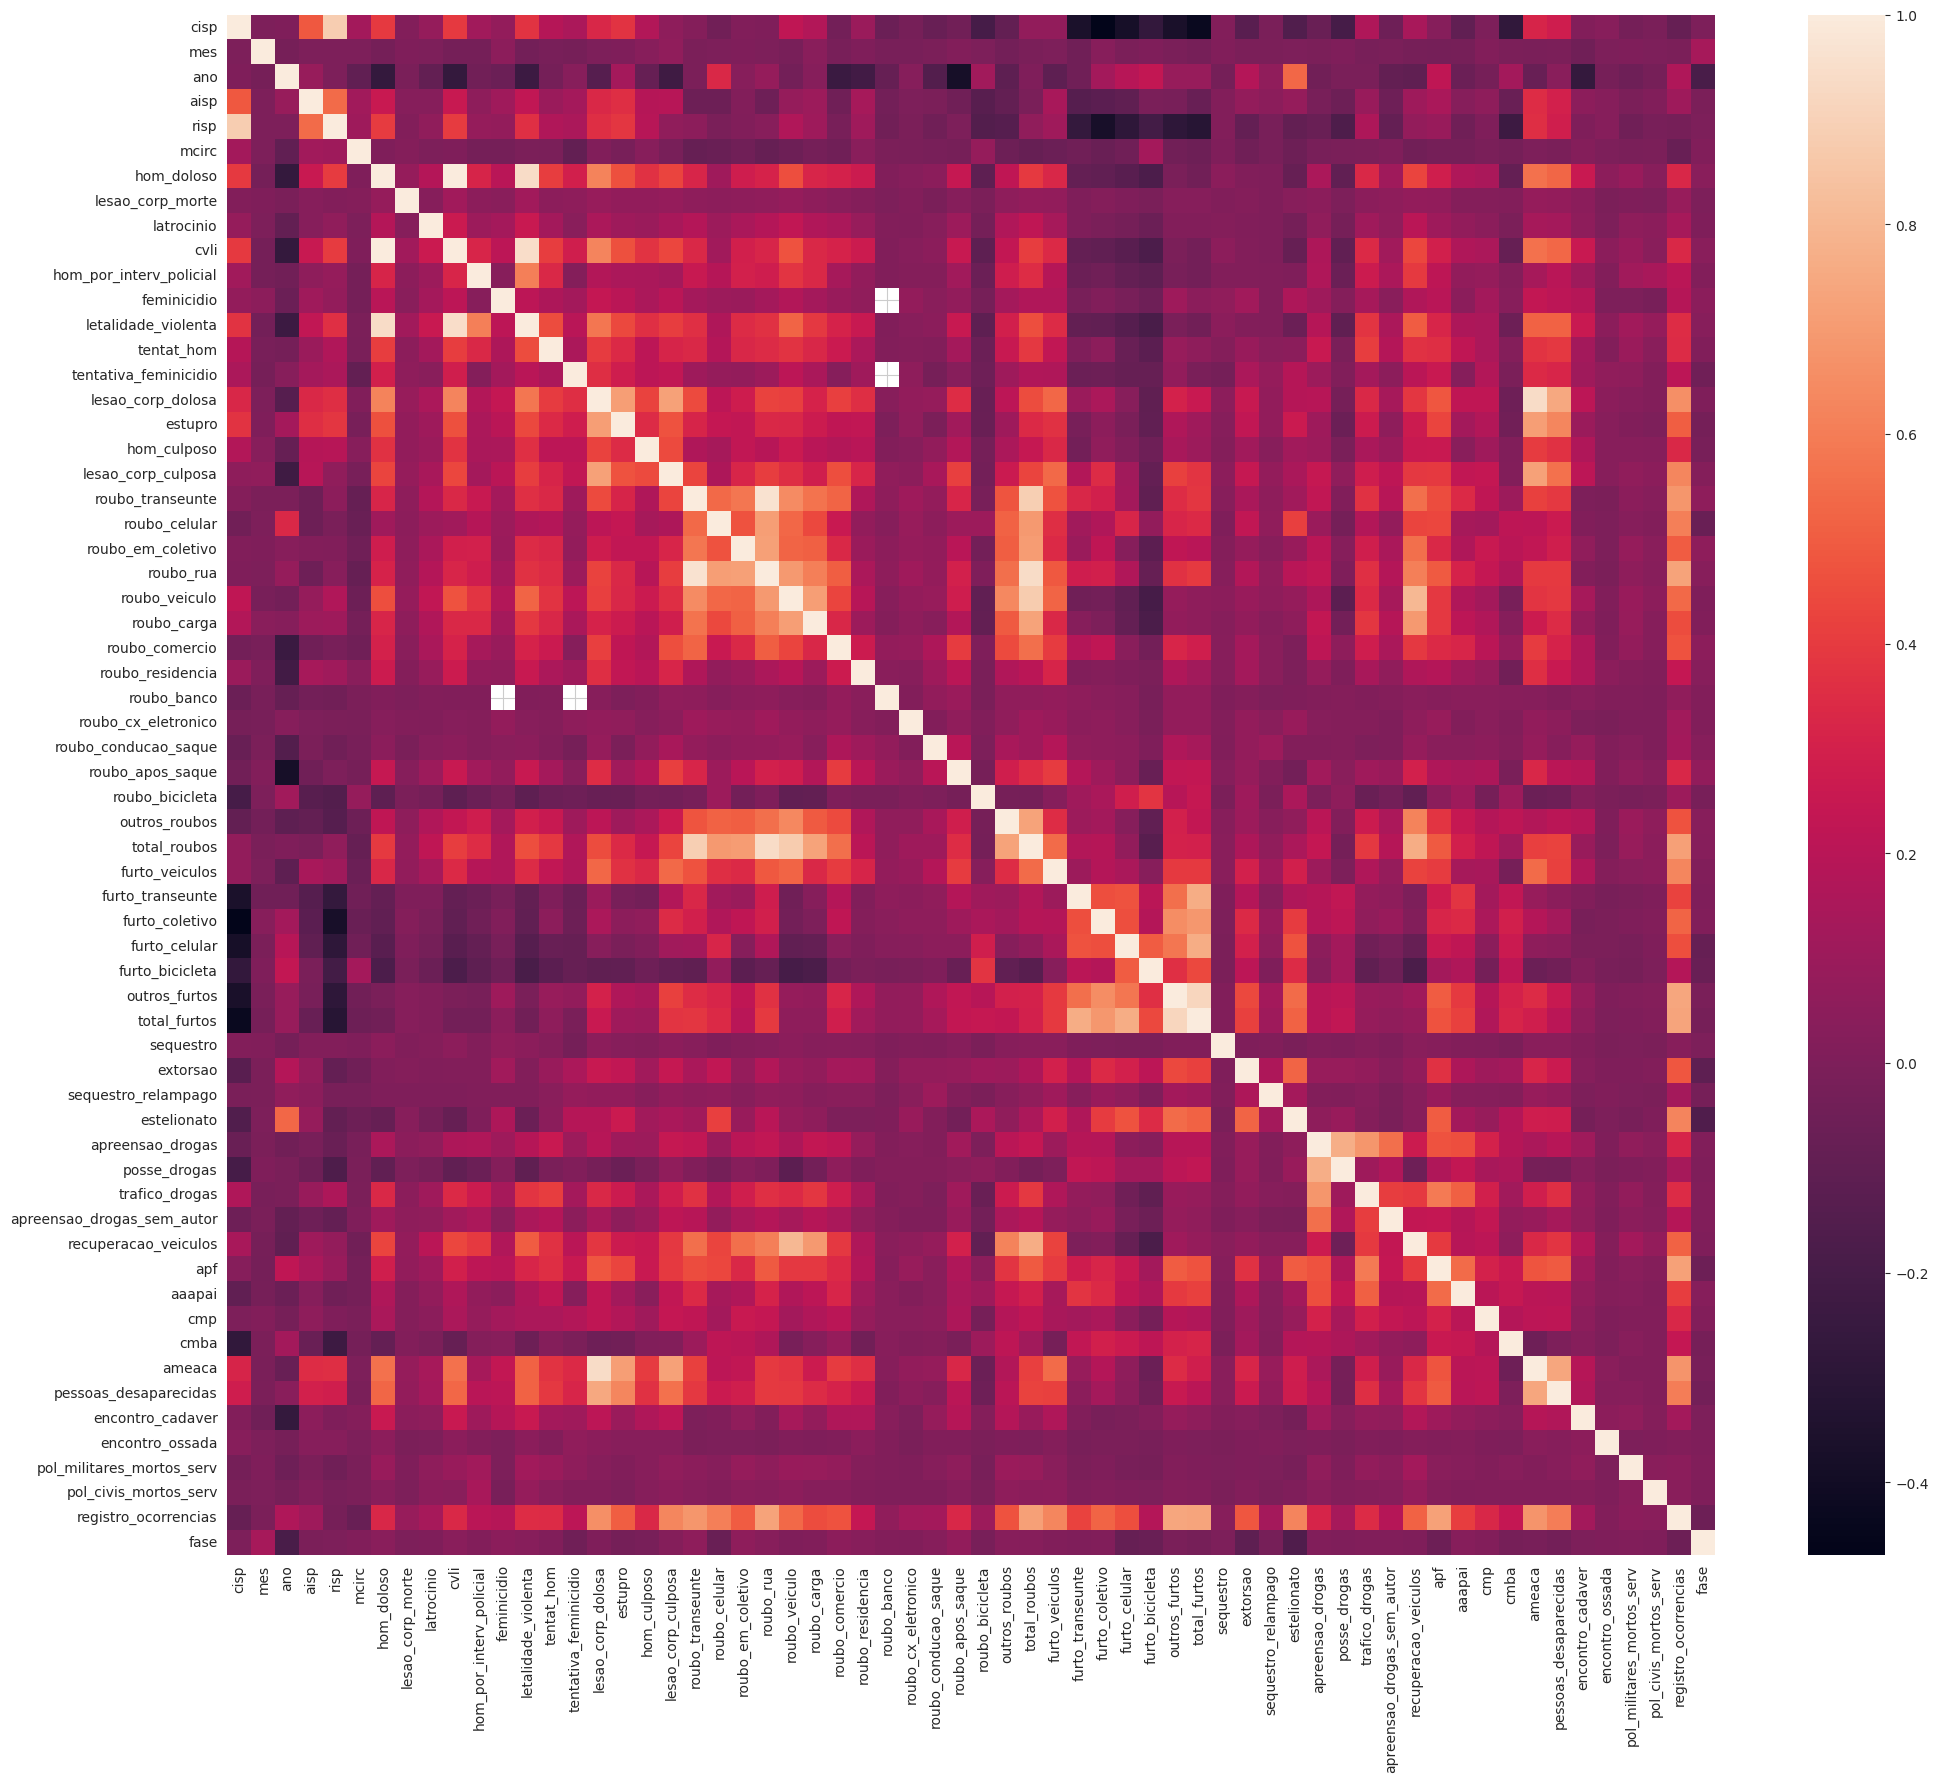

In [11]:
dfnumerical = df.select_dtypes(include=np.number)

plt.figure(figsize=(24,20))
sns.heatmap(dfnumerical.corr())

Selecionando mais delicadamente quais colunas visualizar no heatmap

Text(0.5, 1.0, 'Correlação com Roubo em Coletivo > 0.2')

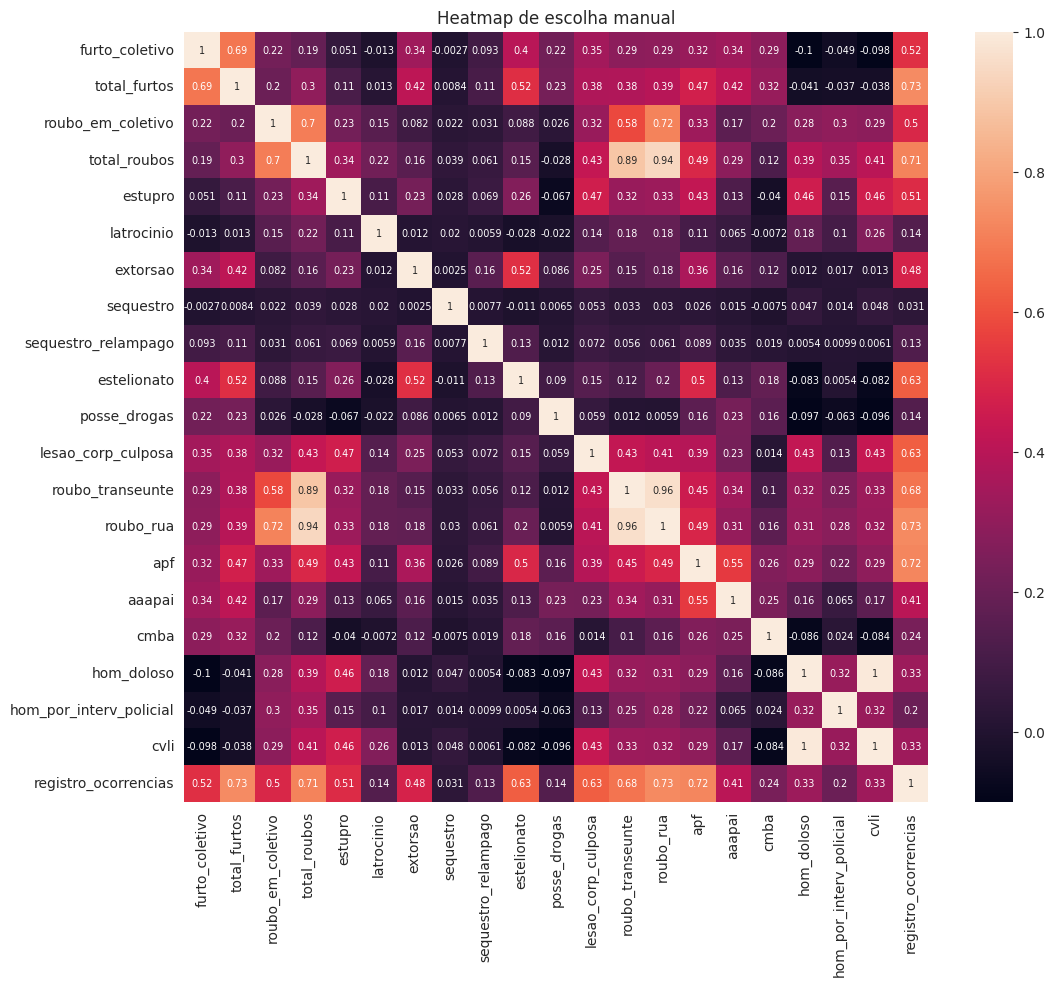

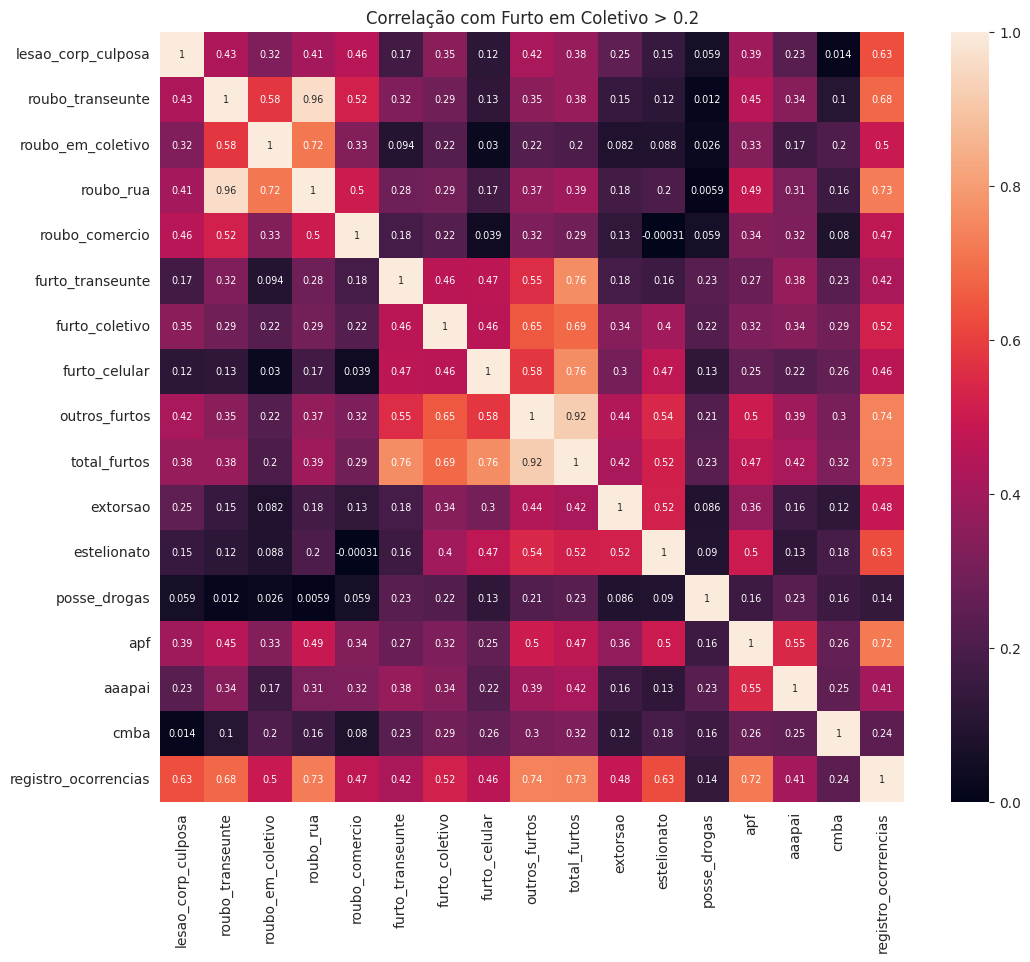

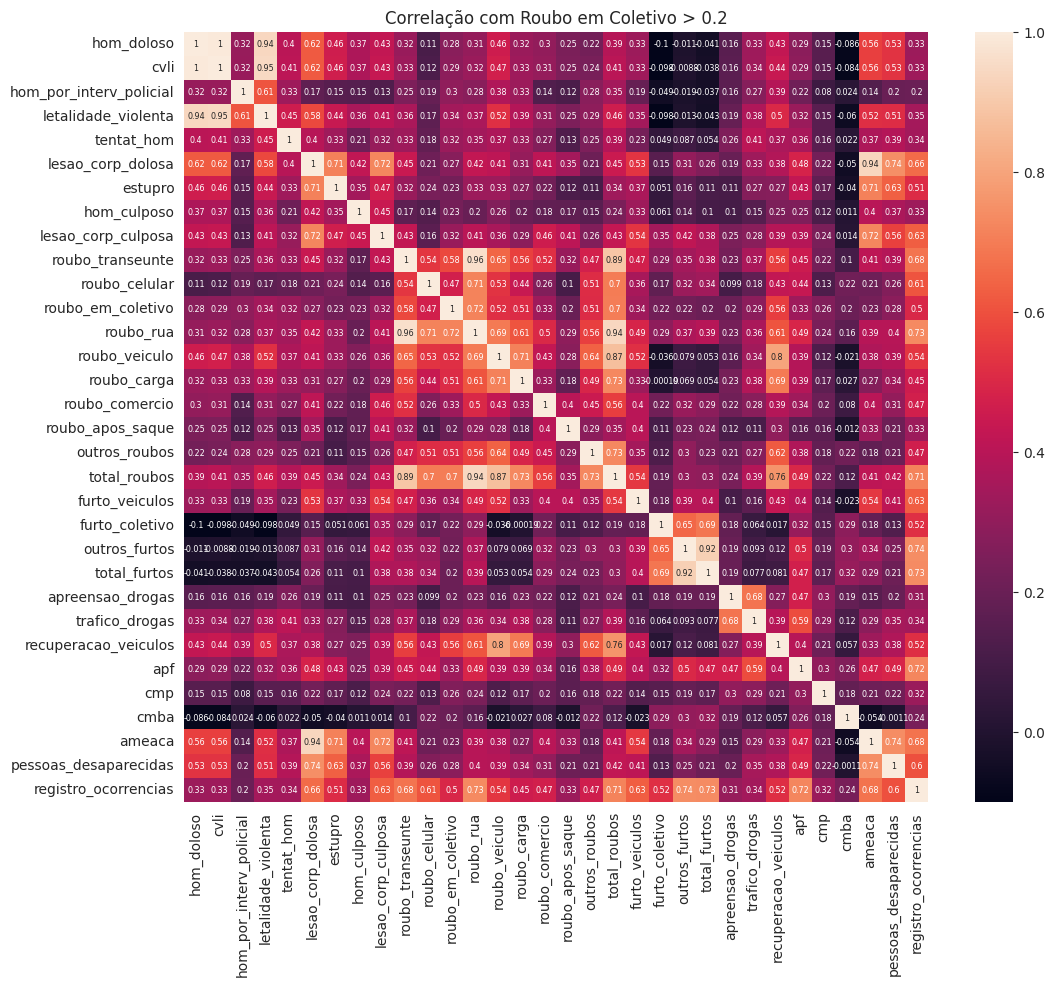

In [18]:
dfheatmapmanual = df[["furto_coletivo", "total_furtos", 
                "roubo_em_coletivo", "total_roubos",
                "estupro",
                "latrocinio",
                "extorsao",
                "sequestro", "sequestro_relampago",
                "estelionato",
                "posse_drogas",
                "lesao_corp_culposa",
                "roubo_transeunte", "roubo_rua",
                "apf", "aaapai", "cmba", # não faço ideia do que seja isso, mas tem uma correlação forte com furto em coletivo
                "hom_doloso", "hom_por_interv_policial",
                "cvli",                  # não faço ideia do que seja isso, mas tem uma correlação forte com roubo em coletivo
                "registro_ocorrencias"]]


plt.figure(figsize=(12,10))
sns.heatmap(dfheatmapmanual.corr(), annot=True, annot_kws={"size": "x-small"}).set_title("Heatmap de escolha manual")

# Fazendo o heatmap somente dos valores que ficam acima de um dado valor (threshold)
threshold = 0.2

dfheatmapcorrfurto = dfnumerical[dfnumerical.corr()[dfnumerical.corr()["furto_coletivo"] > threshold]["furto_coletivo"].keys()].corr()
plt.figure(figsize=(12,10))
sns.heatmap(dfheatmapcorrfurto, annot=True, annot_kws={"size": "x-small"}).set_title(f"Correlação com Furto em Coletivo > {threshold}")

dfheatmapcorrroubo = dfnumerical[dfnumerical.corr()[dfnumerical.corr()["roubo_em_coletivo"] > threshold]["roubo_em_coletivo"].keys()].corr()
plt.figure(figsize=(12,10))
sns.heatmap(dfheatmapcorrroubo, annot=True, annot_kws={"size": "xx-small"}).set_title(f"Correlação com Roubo em Coletivo > {threshold}")

/home/erhari/Desktop/UFRJ-Analytica-PS-2026.1-Grupo-U/venv/lib/python3.14/site-packages/seaborn/axisgrid.py:1513: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  func(x=vector, **plot_kwargs)
/home/erhari/Desktop/UFRJ-Analytica-PS-2026.1-Grupo-U/venv/lib/python3.14/site-packages/seaborn/axisgrid.py:1513: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  func(x=vector, **plot_kwargs)
/home/erhari/Desktop/UFRJ-Analytica-PS-2026.1-Grupo-U/venv/lib/python3.14/site-packages/seaborn/axisgrid.py:1513: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  func(x=vector, **plot_kwargs)
/home/erhari/Desktop/UFRJ-Analytica-PS-2026.1-Grupo-U/venv/lib/python3.14/site-packages/seaborn/axisgrid.py:1513: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  func(x=vector, **plot_kwargs)
/home/erhari/Desktop/UFRJ-Analytica-

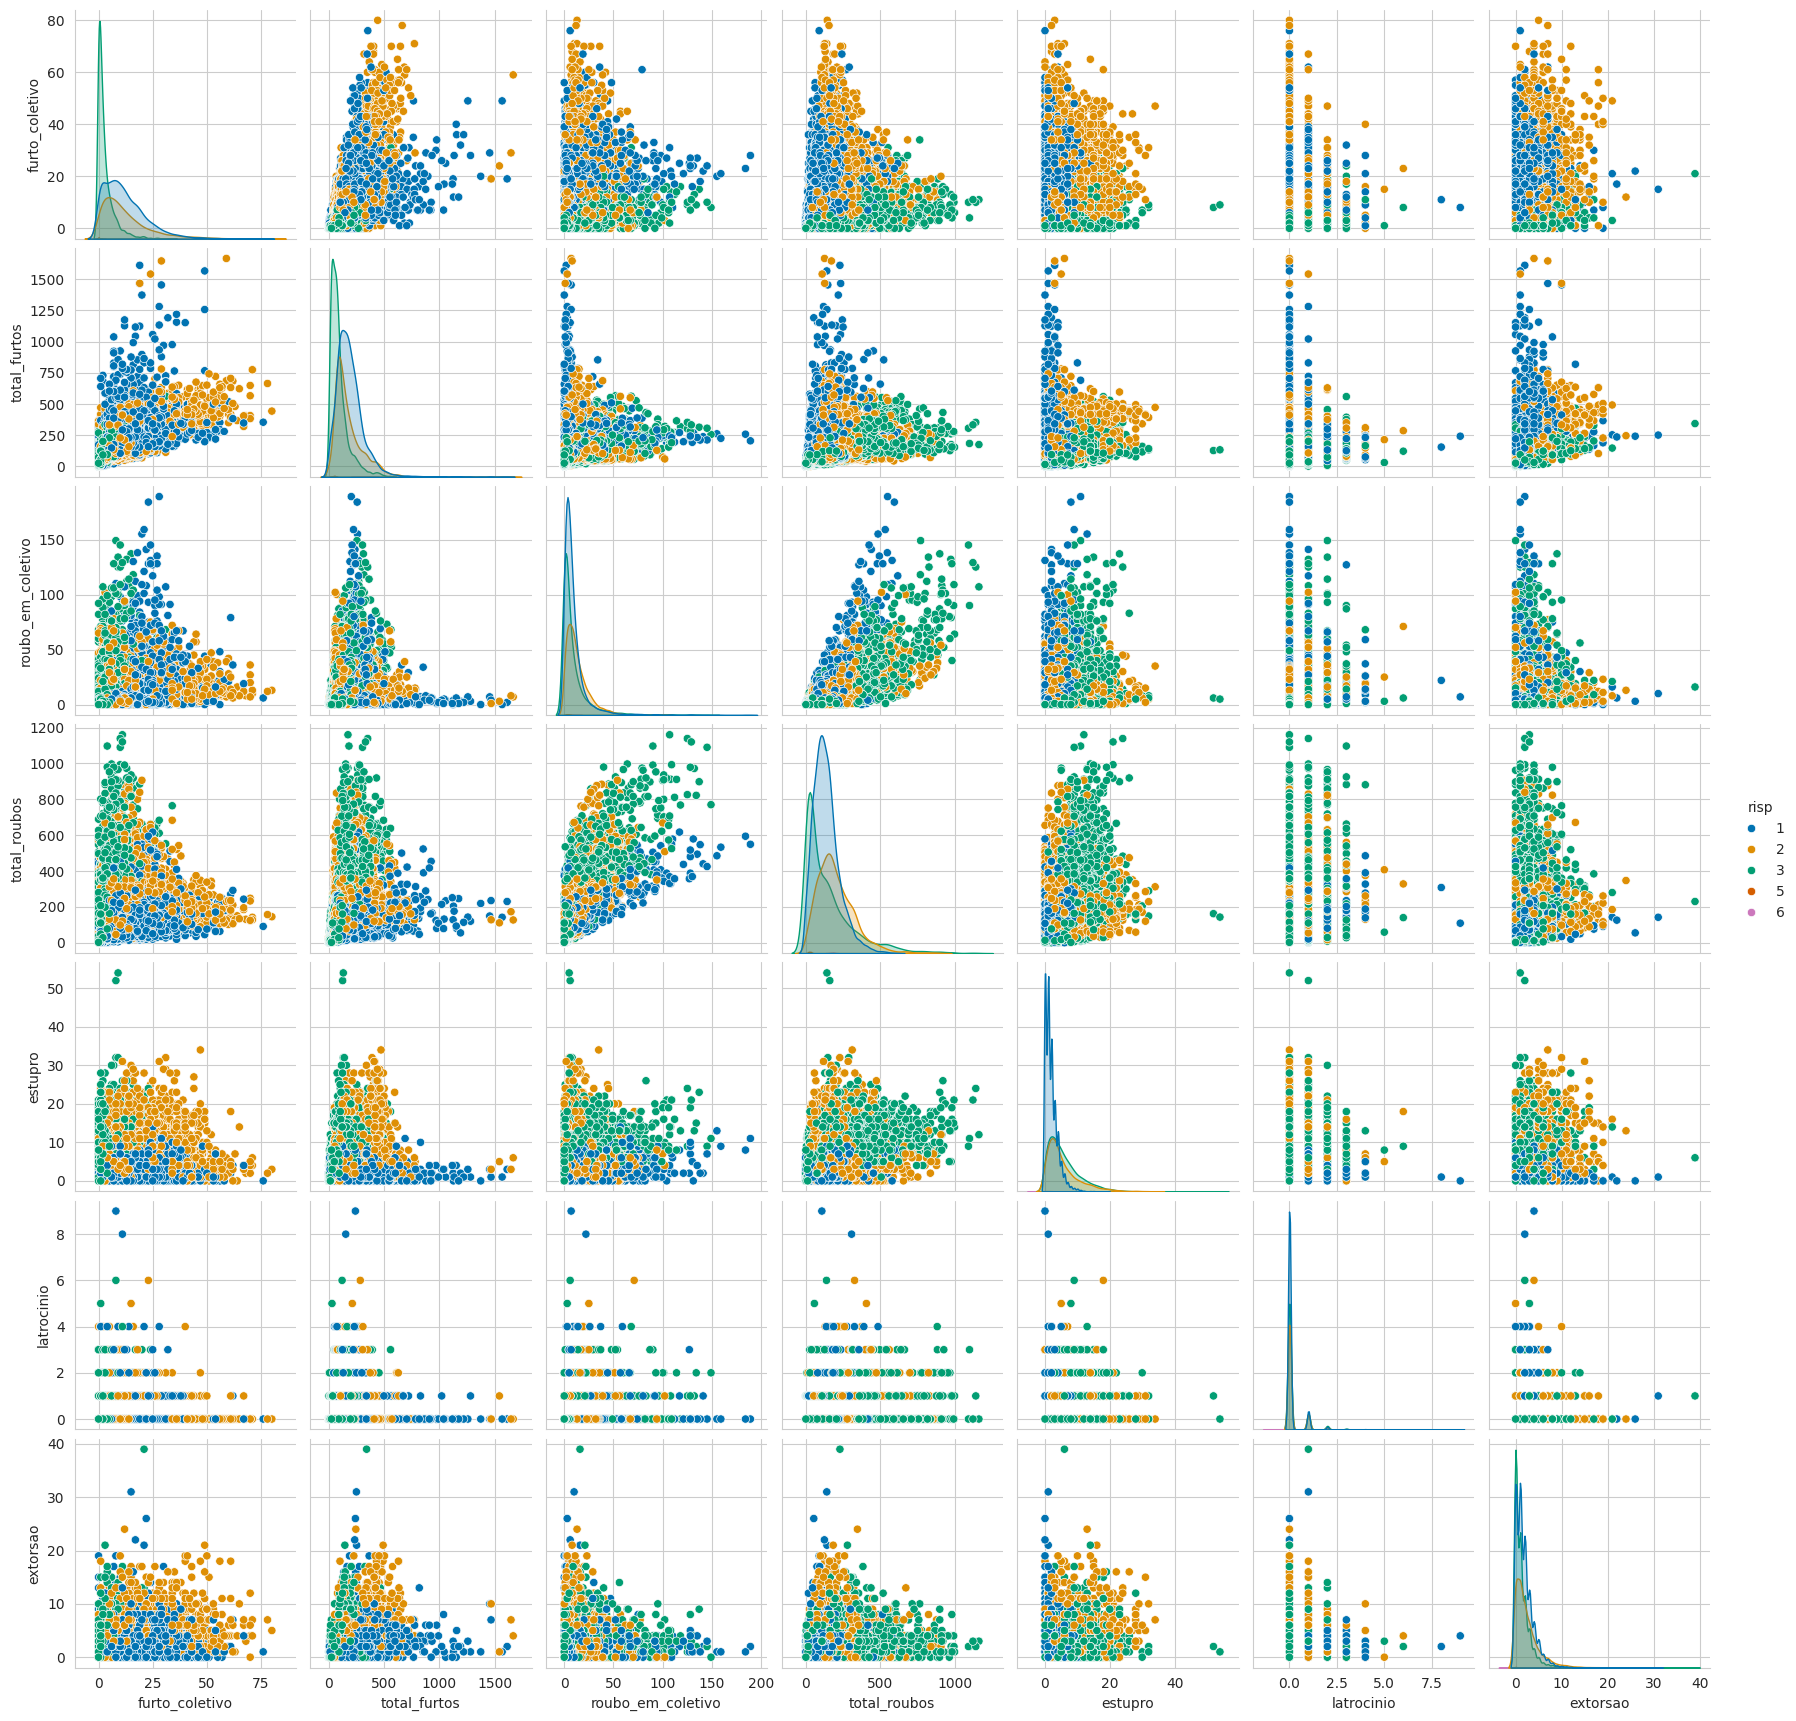

In [13]:
dfpair = df[["furto_coletivo", "total_furtos", 
                "roubo_em_coletivo", "total_roubos",
                "risp",
                "estupro",
                "latrocinio",
                "extorsao"]]

sns.pairplot(dfpair, hue="risp", palette=qualitativepalette) 